# Final Project - Part 2: Stiff ODEs and Implicit Methods - Chemical Reaction with Fast Kinetics

## Section 1: Introduction and System Selection

### System Selection

#### The chosen system for this analysis models a chemical reaction that is characterized by very fast kinetics as it approaches a dynamic equilibrium state. Specifically, it models a simple first-order chemical decay process. The concentration of a chemical rapidly adjusts to match an equilibrium point, but that equilibrium point itself is slowly oscillating over time. This creates a stiff system, where the timescale of the reaction and the changing environment are separated.

#### The first-order ODE that governs this system is:

$\frac{dC}{dt} = -k(C - C_{\text{eq}})$

### For the system to be stiff, we use the following parameters:

$k = 10^4\text{ s}^{-1}$ (very fast reaction rate)

$C_{\text{eq}} = 1 + 0.1\sin(0.1t)$ (slowly varying equilibrium)

Initial condition: $C(0) = 0$

#### This results in the ODE becoming:

$\frac{dC}{dt} = -10^4 C + 10^4(1 + 0.1\sin(0.1t))$

#### The dependent variable C represents the concentration of the chemical species, while t represents time. The parameter k is the reaction rate constant, which in this case is an exceptionally large value that indicates the reaction is incredibly fast. On the other hand, Ceq represents the target equilibrium concentration. The stiffness occurs in the relationship between these two parameters, as the chemical reaction attempts to reach equilibrium very quickly, but the target itself fluctuates slowly over a period of tens of seconds. 

### Importance

#### Systems such as this one frequently occur in combustion chemistry, where localized, rapid ignition reactions occur within a slower-changing thermodynamic environment. Additionally, this framework also models fast kinetics of enzymes in complex biological systems, making the ability to accurately and stably simulate these systems a critical requirement across multiple fields of science.


## Section 2: Stiffness Demonstration

#### To demonstrate the that the system is stiff, we will attempt to solve the system using Euler's Forward method with a step size of h = 0.1

Forward Euler exploded at t = 0.011


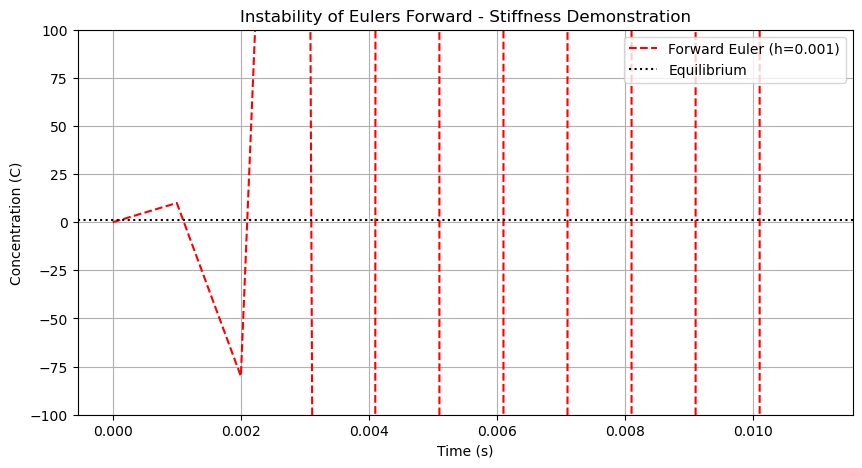

In [52]:
import numpy as np
import matplotlib.pyplot as plt

#initialize variables
k = 10**4
y0 = 0
t0 = 0
tf = 2.0 
h = 0.001 

#Stiff ODE
def f(t, y):
    return -k * y + k * (1 + 0.1 * np.sin(0.1 * t))

#forward Euler method implementation
def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(len(t_values) - 1):
        # forward Euler implementation
        y_values[i+1] = y_values[i] + h * f(t_values[i], y_values[i])
        
        #Kills the method if the values explode beyond 10^9
        if abs(y_values[i+1]) > 1e10:
            print(f"Forward Euler exploded at t = {t_values[i+1]}")
            return t_values[:i+2], y_values[:i+2]
            
    return t_values, y_values

t_fwd, y_fwd = forward_euler(f, y0, t0, tf, h)

#plotting 
plt.figure(figsize=(10, 5))
plt.plot(t_fwd, y_fwd, 'r--', label=f'Forward Euler (h={h})')
plt.axhline(1.0, color='black', linestyle=':', label='Equilibrium')
plt.ylim([-1e2, 1e2]) # Limit Y to see the start of the divergence
plt.xlabel('Time (s)')
plt.ylabel('Concentration (C)')
plt.title('Instability of Eulers Forward - Stiffness Demonstration')
plt.legend()
plt.grid(True)
plt.show()


#### Normally, this small of a step size would be sufficient for the method to stay stable. However, the method still ends up becoming unstable and exploding to unreasonable numbers very soon (t = 0.011 seconds). This demonstration shows that a very small, computationally unreasonable step size is required for the solution to stay stable. 

### Stiffness ratio

#### To calculate the stiffness ratio, we look at the ratio of the largest magnitude eigenvalue to the smallest magnitude eigenvalue in the system. In this case, the eigenvalues represent the reaction rate of the chemical reaction at the slow and fast timescales corresponding to the equilibrium oscillation and reaction rate. The large eigenvalue is associated with the fast chemical reaction $\lambda_1 = -10^4$, while the small eigenvalue is the frequency of the equilibrium oscillation, where $\omega = 0.1$. 

#### The resulting stiffness ratio is: 

$$\text{Stiffness Ratio} = \frac{|\lambda_{max}|}{|\lambda_{min}|} = \frac{10^4}{0.1} = 10^5$$

#### This value confirms that the system is extremely stiff, and represents the disparity between the speed of the chemical decay and the speed of the environmental change. As a result, the solver must track a process that takes tens of seconds to unfold while accounting for millisecond-level changes, resulting in the need for very, very small step sizes in Euler's forward.

### Step size requirement and impracticality

#### For an explicit method to be stable on the ODE $y' = -\lambda y$, the step size has to meet the requirement of $h < 2/|\lambda|$. Calculating for this required step size, we find that:

$$h_{\text{stable}} < \frac{2}{10^4} = 0.0002\text{ s}$$

#### Such a tiny step size is extremely impractical and computationally expensive. To capture approximately one full cycle of the equilibrium oscillation by simulating for 50 seconds, the number of required steps would be 50/0.0002, or 250,000 steps. In contrast, an implicit method such as Backwards Euler is unconditionally stable, meaning that it can accurately simulate the equilibrium wave using a step size of h = 0.1. What this means is that the explicit method requires 500 times the computational effort simply to avoid becoming unstable, without the added benefits of useful information beyond what the implicit method is capable of. Therefore, using an implicit method in solving this ODE is a necessity to avoid a computational burden and instability.

## Section 3: Mathematical Setup

#### To step the solution forward in time using Implicit Euler and apply the Newton-Raphson method, we must first define the residual function $g(C_{n+1})$.

#### In this case, the concentration C acts as our dependent variable y. This must equal zero when the true value of Cn+1 is found. We can substitute our governing ODE into the residual equation:

$g(y_{n+1}) = y_{n+1} - y_n - h \cdot f(t_{n+1}, y_{n+1}) = 0$

#### After doing so, we get:

$g(C_{n+1}) = C_{n+1} - C_n - h \left[ -10^4 C_{n+1} + 10^4(1 + 0.1\sin(0.1t_{n+1})) \right] = 0$

#### The next step is the analytical derivation of the residual function with respect to the unknown variable Cn+1. When we apply the chain rule to the residual function, the general derivative is:

$g'(C_{n+1}) = 1 - h \cdot \frac{\partial f}{\partial C}$

#### Because the governing ODE takes the linear form $dC/dt = -\lambda C + G(t)$ with $\lambda = 10^4$, the analytical derivative $g'$ is completely independent of $C_{n+1}$. This makes the computation particularly simple: for a given step size $h$, the denominator $1 + 10^4 h$ is constant and only needs to be calculated once per time step, rather than at every iteration $k$.

#### Thus, the analytical derivative of the function simplies to:

$\frac{\partial f}{\partial C} = -10^4$

#### This allows the analytical derivative of the residual function to simplify to:

$g'(C_{n+1}) = 1 - h(-10^4) = 1 + 10^4 h$

#### Finally, we can construct the specific Newton-Raphson update formula for this problem. The standard iteration formula is:

$C_{n+1}^{(k+1)} = C_{n+1}^{(k)} - \frac{g(C_{n+1}^{(k)})}{g'(C_{n+1}^{(k)})}$

#### We can plug in our specific residual function and its derivative and arrive at the full Newton-Raphson update formula:

$$C_{n+1}^{(k+1)} = C_{n+1}^{(k)} - \frac{C_{n+1}^{(k)} - C_n - h \left[ -10^4 C_{n+1}^{(k)} + 10^4(1 + 0.1\sin(0.1t_{n+1})) \right]}{1 + 10^4 h}$$

## Section 4: Implementation

### Function defining the ODE:

In [41]:
import numpy as np
import matplotlib.pyplot as plt

#Governing ODE
def f(t, y):
    return -10**4 * y + 10**4 * (1 + 0.1 * np.sin(0.1 * t))

### Newton Raphson Solver

In [42]:
# Newton-Raphson method with 20 iterations and a tolerance of 10^-6 as specified
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=20):
    x = x0
    for i in range(max_iter):
        x_new = x - g(x) / dg(x)
        # convergence tolerance
        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
    return None, max_iter

### Backward Euler Method with NR Iteration

In [43]:
#Backwards Euler method using Newton-Raphson iteration
def backward_euler(f, y0, t0, tf, h):

    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    #Number of iterations per step
    iterations_track = []

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]

        # Residual function
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        
        # Analytical derivative
        dg = lambda y_next: 1 - h * (-10**4)
        
        #Explicit Euler Predictor
        y_guess = y_prev 
        
        #Solving for the next step using Newton-Raphson
        y_next, iters = newton_raphson(g, dg, x0=y_guess, tol=1e-6, max_iter=20)
        
        if y_next is None:
            raise ValueError(f"Newton-Raphson failed to converge at t={t_next}")

        #adds this value to the results
        y_values[i] = y_next
        iterations_track.append(iters)

    return t_values, y_values, iterations_track

## Section 5: Results and Analysis

### Backwards Euler with Newton-Raphson output for 3 step sizes

Step size h = 1.0
Total time steps: 50
Step size h = 0.5
Total time steps: 100
Step size h = 0.1
Total time steps: 500
Step size h = 0.01
Total time steps: 5000


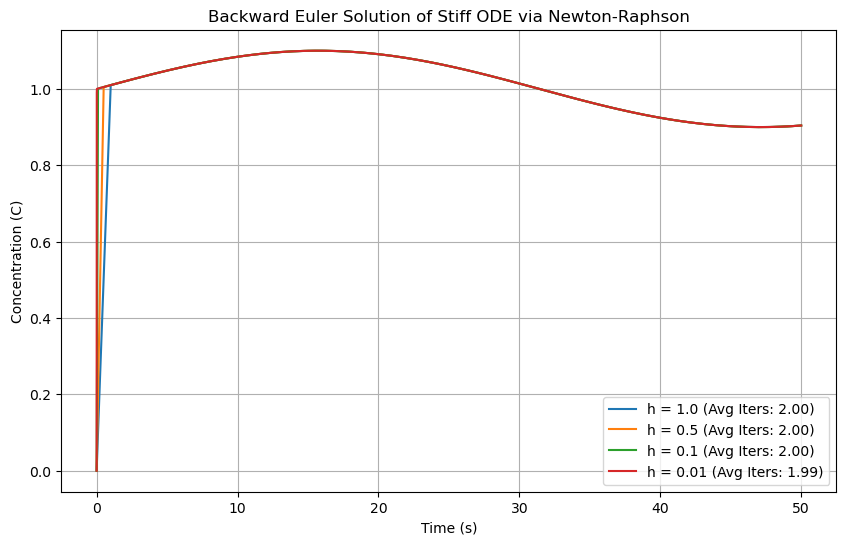

In [44]:
y0 = 0
t0 = 0
tf = 50.0 

#varying step sizes for different solutions
step_sizes = [1.0, 0.5, 0.1, 0.01] 

plt.figure(figsize=(10, 6))

for h in step_sizes:
    t_vals, y_vals, iters = backward_euler(f, y0, t0, tf, h)
    
    #Total steps
    avg_iters = np.mean(iters)
    max_iters = np.max(iters)
    print(f"Step size h = {h}")
    print(f"Total time steps: {len(iters)}")
    
    #results plotting
    plt.plot(t_vals, y_vals, label=f'h = {h} (Avg Iters: {avg_iters:.2f})')

plt.xlabel('Time (s)')
plt.ylabel('Concentration (C)')
plt.title('Backward Euler Solution of Stiff ODE via Newton-Raphson')
plt.legend()
plt.grid(True)
plt.show()

##### Discussion:

##### All step sizes are relatively stable and follow the expected solution curve well, even as the step sizes increase in orders of magnitude. This demonstrates the unconditional stable nature of Euler's Backward.

### Step Size Comparison Between Euler's Forward and Backward

#### In section 2, we found that the maximum step size for Euler's forward is 0.0002 seconds.

#### Euler's Backward and Maximum Step Size:

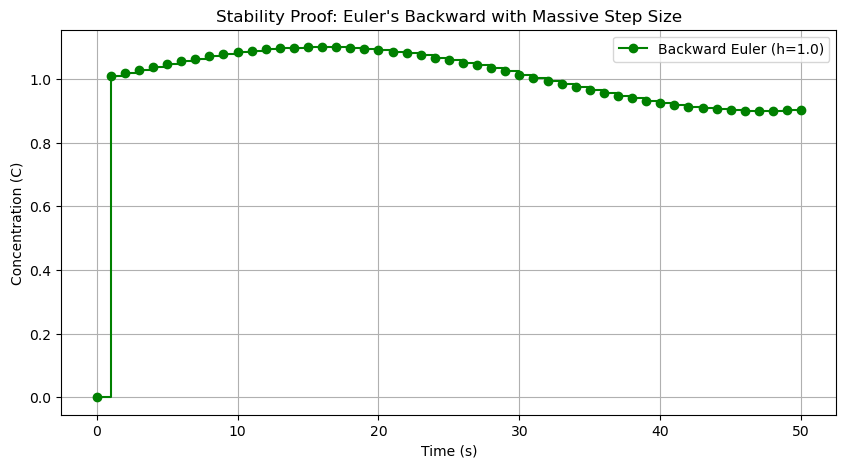

In [53]:
import numpy as np
import matplotlib.pyplot as plt

#initial values
y0 = 0
t0 = 0
tf = 50.0 

#this h is 5,000x the stability limit of Forward Euler - much more massive in comparison
h_massive = 1.0 

#data retrieved from method
t_max, y_max, _ = backward_euler(f, y0, t0, tf, h_massive)

#plotting 
plt.figure(figsize=(10, 5))
plt.step(t_max, y_max, where='post', label=f'Backward Euler (h={h_massive})', color='green', marker='o')
plt.title('Euler\'s Backward with Massive Step Size')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (C)')
plt.legend()
plt.grid(True)
plt.show()

##### Discussion:

##### In the graph above, we can visually see that the backwards Euler method is still converging to the same equilibrium without becoming unstable and exhibiting violent oscillations, even with a step size of 1 second. This step size is 5000x the size of the maximum step size Euler's Forward is able to handle, demonstrating that Euler's backward has a limit to its step size far above that of Euler's Forward. This also demonstrates the unconditional stability that Euler's Backward exhibits, where the method will remain stable regardless of how large the step size is, due to its stability region covering the left half of the complex plane. Thus, even with increasing step size, Euler's Backward is far more stable.

| Numerical Method | Stability Condition | Max Stable Step Size ($h_{\text{max}}$) | Steps for 50s Sim |
| :--- | :--- | :--- | :--- |
| **Euler's Forward** | $h < 2/|\lambda|$ | $0.0002$ s | $\ge 250,000$ |
| **Euler's Backward** | Unconditionally Stable | No mathematical limit* | $\sim 50 - 500$ |


### Convergence Behavior

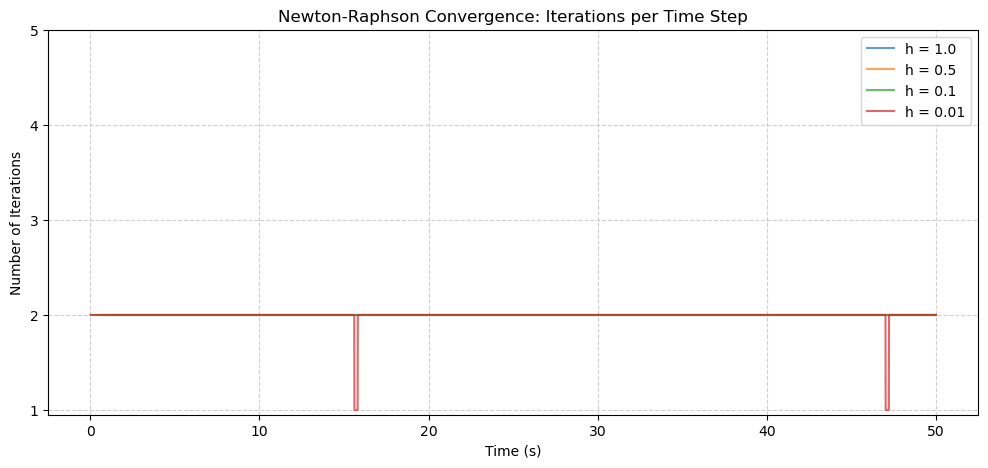

Step size 1.0: Max iterations = 2, Avg iterations = 2.00
Step size 0.5: Max iterations = 2, Avg iterations = 2.00
Step size 0.1: Max iterations = 2, Avg iterations = 2.00
Step size 0.01: Max iterations = 2, Avg iterations = 1.99


In [46]:
plt.figure(figsize=(12, 5))
for h in step_sizes:
    t_vals, _, iters = backward_euler(f, y0, t0, tf, h)
    #iterations vs. time
    plt.plot(t_vals[1:], iters, label=f'h = {h}', alpha=0.7)

#plotting iterations 
plt.title('Newton-Raphson Convergence: Iterations per Time Step')
plt.xlabel('Time (s)')
plt.ylabel('Number of Iterations')
plt.yticks([1, 2, 3, 4, 5]) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#iteration counts printed
for h in step_sizes:
    r1, r2, iters = backward_euler(f, y0, t0, tf, h)
    print(f"Step size {h}: Max iterations = {max(iters)}, Avg iterations = {np.mean(iters):.2f}")

##### Discussion:

##### Interpreting the data in the graph, step sizes h = 1.0 and h = 0.1 are straight lines hovering around 2 iterations, while step size h = 0.01 has dips to 1 iteration. The convergence behavior across all three step sizes is almost identical, indicating that for this stiff ODE, the method works solidly with large step sizes. The method does not struggle at all to follow the equilibrium, even with a very large step size of h = 1.0. Using the explicit Euler predictor as the initial guess proves to be a high-quality choice, given that the solution consistently achieves convergence in 2 iterations. In fact, for step size h = 0.01, the choice allows some points to already be in the specified tolerance when calculating the chance between $y_(n)$ and $y_(n+1)$, allowing the solver to exit without needing an extra step.

##### Perhaps the most important quality that explains this convergence is that the governing ODE is linear with respect to C. This results in the Newton-Raphson method finding the exact root in one iteration because it guesses using a tangent line. The only reason why the plot shows 2 iterations is that the solver first takes a step and then evaluates the change on the next iteration. If this system were nonlinear, the iteration counts would have to increase, as the Newton-Raphson method would have to guess multiple tangent lines to find the root along a curve.

### Solution Quality and Error Analysis

#### To evaluate the solution quality, we have to first find the analytical solution. The analytical solution will be in the form of:
$$y(t) = e^{-\lambda t} y_0 + \int_{0}^{t} e^{-\lambda(t-s)} g(s) ds$$
#### In our system,  $\lambda = 10^4$ and $g(s) = 10^4(1 + 0.1\sin(0.1s))$. Since $\lambda$ is very large, the $e^{-\lambda t}$ term decays to zero almost instantly, and the integral term dominates in the long run, forcing $y(t)$ to track $C_{\text{eq}}$ with a very slight delay. The analytical solution becomes:

$$C(t) = \int_{0}^{t} e^{-10^4(t-s)} \left[ 10^4(1 + 0.1\sin(0.1s)) \right] ds$$

#### Error Analysis:

In [47]:
def analytical_solution(t, y0=0, k=1e4):
    # fast growth
    term_fast = (1 - np.exp(-k * t))
    # slow oscillation
    c = (k * 0.1) / (k**2 + 0.1**2)
    term_slow = c * (k * np.sin(0.1 * t) - 0.1 * np.cos(0.1 * t) + 0.1 * np.exp(-k * t))
    
    return term_fast + term_slow

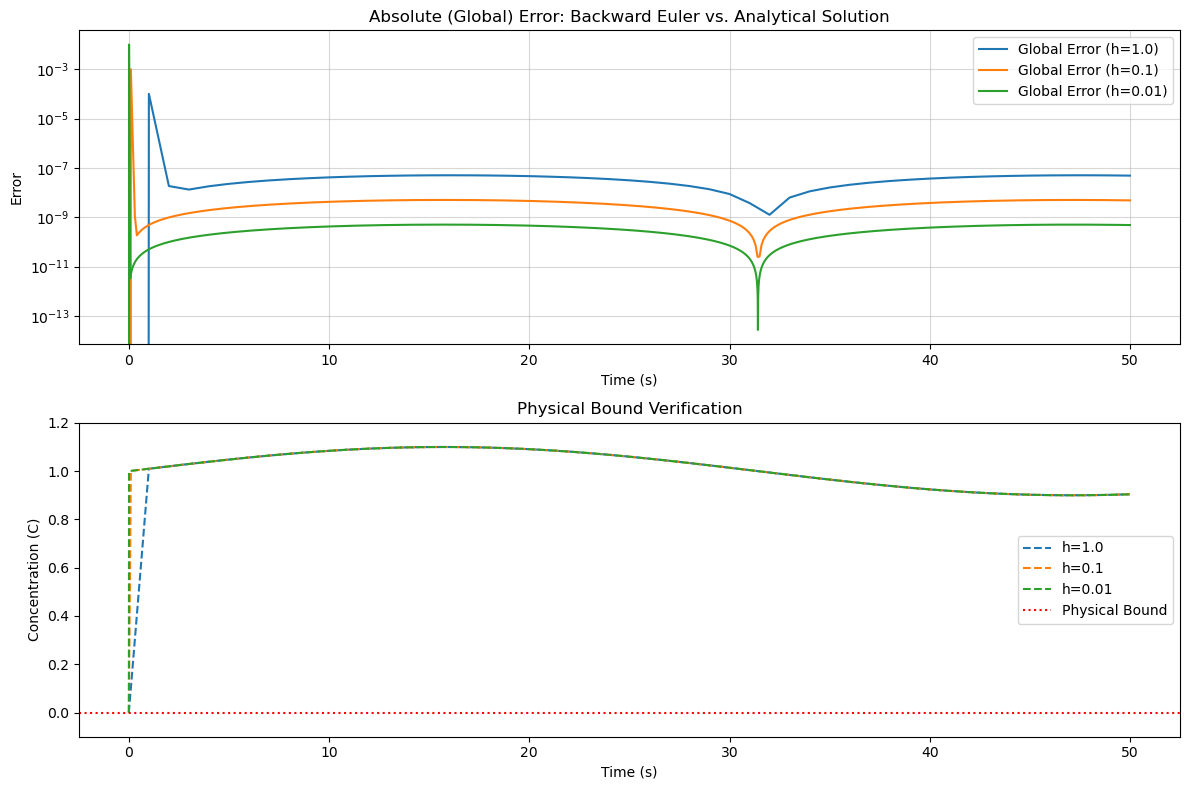

In [48]:
import numpy as np
import matplotlib.pyplot as plt

step_sizes = [1.0, 0.1, 0.01]
plt.figure(figsize=(12, 8))

#global error plotting
plt.subplot(2, 1, 1)
for h in step_sizes:
    t_vals, y_vals, _ = backward_euler(f, y0, t0, tf, h)
    #calculating the true value at the exact same time points
    y_true = analytical_solution(t_vals)
    #calculating the absolute (global) error
    error = np.abs(y_vals - y_true)
    plt.semilogy(t_vals, error, label=f'Global Error (h={h})')

plt.title('Absolute (Global) Error: Backward Euler vs. Analytical Solution')
plt.xlabel('Time (s)')
plt.ylabel('Error')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

#physical bounds verification
plt.subplot(2, 1, 2)
for h in step_sizes:
    t_vals, y_vals, _ = backward_euler(f, y0, t0, tf, h)
    plt.plot(t_vals, y_vals, '--', label=f'h={h}')

plt.axhline(0, color='red', linestyle=':', label='Physical Bound')
plt.title('Physical Bound Verification')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (C)')
plt.ylim([-0.1, 1.2]) # Focus on the bound
plt.legend()
plt.tight_layout()
plt.show()

##### Discussion:

##### When examining whether the solution remains in the physical bounds, the concentration C remains non-negative throughout the simulation (C > 0). The Backward Euler method does not produce any negative concentrations or wild oscillations, demonstrating that the method is exceptionally stable even at varying step sizes. When examining if any fast transients are resolved correctly, smaller step sizes perform better than larger step sizes in resolving the transient between t = 0 s and t = 0.001 s. For the larger step sizes, the solution cannot resolve the transient in detail because it steps past the transient and instead goes straight to the equilibrium. With smaller step sizes, even though the error spikes higher, it is actually trying to capture the full extent of the transient and, as a result, has a higher error than a step size that simply skips it. Once the solution passes the transient, the solution tracks the equilibrium perfectly. The error remains low even on the highest step size, confirming that the Backward Euler method is highly effective at capturing the long-term changes of the system despite the stiffness.

## Section 6: Performance Analysis

### Accuracy vs. Computation Costs

In [54]:
import numpy as np

#function that displays all valuable data neatly
def calculate_cost_comparison(f, y0, t0, tf):
    results = []
    #Backwards Euler Cases
    for h in [1.0, 0.1, 0.01]:
        t_vals, nullvalue, iters = backward_euler(f, y0, t0, tf, h)
        total_steps = len(t_vals) - 1
        avg_iters = np.mean(iters)
        total_evals = total_steps * avg_iters
        results.append(["Backward Euler", h, total_steps, f"{avg_iters:.2f}", int(total_evals)])
    
    #forward Euler's cost at stability limit
    h_stable_fwd = 0.0002
    fwd_steps = int(tf / h_stable_fwd)
    results.append(["Forward Euler", h_stable_fwd, fwd_steps, "1.00", fwd_steps])
    
    return results

#tabled results
print(f"{'Method':<18} | {'h':<8} | {'Steps':<8} | {'Avg Iters':<10} | {'Total Evals'}")
print("-" * 65)
for res in calculate_cost_comparison(f, y0, t0, tf):
    print(f"{res[0]:<18} | {res[1]:<8} | {res[2]:<8} | {res[3]:<10} | {res[4]}")

Method             | h        | Steps    | Avg Iters  | Total Evals
-----------------------------------------------------------------
Backward Euler     | 1.0      | 50       | 2.00       | 100
Backward Euler     | 0.1      | 500      | 2.00       | 1000
Backward Euler     | 0.01     | 5000     | 1.99       | 9960
Forward Euler      | 0.0002   | 250000   | 1.00       | 250000


### Discussion and Recommendations

##### The computational cost of a numerical solver is primarily measured by the total number of evaluations the function has to process to reach the desired time. For the Backward Euler, we can find this by multiplying the number of time steps and the number of Newton-Raphson iterations per time step. For Forward Euler, the value is simply the total time divided by the time step h. The table produced by the code above compares the performance of the Forward Euler and Backward Euler methods for a 50-second simulation.

##### The results show that the Forward Euler method is far more computationally expensive to run, even with the step size nearing its stability limit. On the other hand, the Backward Euler method is far less computationally intensive, which allows the users to choose the step size based on the accuracy requirements rather than stability. For example, a user may want to use a smaller step size when evaluating the transients, while bigger step sizes may be used for long-term trends. The bottom line is that the Backward Euler is far less computationally expensive to run, allowing the user to choose between accuracy and efficiency.

##### From this investigation, it is recommended that, for any system with a very high stiffness ratio, explicit methods should be avoided due to having to meet stability, resulting in massive computational costs. For general purposes, h = 0.1 is a good step size for this ODE as it captures the oscillatory equilibrium well while being computationally efficient.

## Section 7: Conclusions

#### This investigation resulted in the successful modeling of a stiff first-order ODE characterized by a massive stiffness ratio of 10^5. My key finding was that implicit solvers performed far better than explicit solvers in terms of stability and computational costs when compared to accuracy. While the Forward's Euler required 250,000+ steps and a very small step size to maintain stability, the Backward Euler with Newton-Raphson model maintained perfect stability with 5000x less steps. Furthermore, Newton-Raphson converged very efficiently, only requiring 2 iterations to find the root at each time step.

#### The general rule is that for stiff systems, impplicit methods should be used, while explicit methods can be used for non-stiff systems where the timescales are closely grouped. One interesting challenge that I encountered was interpreting the absolute error. While it appeared that smaller step sizes led to higher error in trying to solve the fast transient, it actually represented the smaller step's ability to pick up on that transient rather than just skip over it entirely. This led to the lesson that in order to interpret error, we have to interpret the context that the error is found in and how it shows the interaction between the analytical solution and the model solution.

## Appendix

#### AI Usage:

##### I used Gemini AI in section 2 to help me format my graph to be better readable and interpretable.
##### I used Gemini AI in section 3 to help me derive the formulas for this specific ODE
##### I used Gemini AI in section 4 to help me clean up the syntax of the function integration
##### I used Gemini AI in section 5 to help me derive functions for the convergence proof and error estimation, as well as making the graphs readable and interpretable.
##### I used Gemini AI in section 6 to help me create a function that displays all useful metrics in that section.